# **Introduction to Machine Learning**

## STAT 362 — Advanced Machine Learning · Adi Rosenstock

### Professor: Emre Besler

### September 24, 2026

## 1. What is Machine Learning?

**ML = Data Science ∩ AI.** Learn patterns from **data + algorithms** instead of
explicitly programming every decision rule:

> **Data → Learning Algorithm → Model → Predictions / Patterns**

A model becomes "intelligent" by being **trained on data**.
**Deep Learning** = ML built on Artificial Neural Networks (AI ⊃ ML ⊃ DL).

### The three categories

| | Data has targets? | Goal | Methods |
|---|---|---|---|
| **Supervised** | Yes (labels $y$) | Predict a target | Regression (continuous $y$), Classification (discrete $y$) |
| **Unsupervised** | No — only $X$ | Discover structure | Clustering, Component analysis |
| **Anomaly detection** | Either | Find observations that aren't ordinary | Supervised, unsupervised, or both |

Supervised learning learns $X \rightarrow y$, i.e. a function $\hat{y} = f(X)$ that
predicts the target for **new** observations.

**Not ML:** systems that skip data modeling and feature engineering — *Garbage In, Garbage Out*.

# **Linear Regression with Gradient Descent**

## 2. The Model and Its Cost

$$
y = w_0 + w_1x_1 + \cdots + w_Nx_N
\qquad\Longleftrightarrow\qquad
f(\mathbf{x}) = \mathbf{w}^T\mathbf{x}
$$

with $\mathbf{x}^{(i)} = [1, x_1^{(i)}, \ldots, x_N^{(i)}]^T$ (the leading $1$ carries the intercept).

> **Training = finding the parameters $\hat{\mathbf{w}}$ that minimize the cost.**

The cost must be in terms of the **data** ($x$, $y$) and the **parameters** ($w$).
For Linear Regression it is the **Mean Squared Error**: error per observation
$e^{(i)} = y^{(i)} - f(\mathbf{x}^{(i)})$, squared, averaged:

$$
MSE
= \frac{1}{M}\sum_{i=1}^{M}\left(e^{(i)}\right)^2
= \frac{1}{M}\sum_{i=1}^{M}\left(y^{(i)} - \mathbf{w}^T\mathbf{x}^{(i)}\right)^2
$$

### Two ways to minimize it

**1. Least Squares (closed form).** Set the gradient to $0$ and solve:

$$
\hat{\mathbf{w}} = (X^TX)^{-1}X^T\mathbf{y}
$$

Exact, but **only works for Linear (and Ridge) Regression** and is **not useful for big data**.
*Not covered — derivation is on Canvas.*

**2. Gradient Descent.** ← what this course uses

## 3. Gradient Descent

A **numeric** method: it finds a *"close enough"* solution rather than an exact one.
Start from a random $\mathbf{w}$ and iteratively step downhill.

**Why we care:** works for **any** cost function (essential for Logistic Regression and
Neural Networks) and is **very efficient with big data**.

### The cost is a function of $\mathbf{w}$ alone

The $\mathbf{x}^{(i)}$ and $y^{(i)}$ are **data — constants**. Only $\mathbf{w}$ varies:

$$
MSE(\mathbf{w}) = \frac{1}{M}\sum_{i=1}^{M}\left(y^{(i)} - \mathbf{w}^T\mathbf{x}^{(i)}\right)^2
$$

- One feature, **no intercept** ($y = wx$): $MSE(w)$ is a **parabola**.
- One feature, **with intercept** ($y = w_0 + w_1x$): $MSE(w_0, w_1)$ is a **bowl**.

> **Key property:** in *any* number of dimensions the MSE cost is **strictly convex**
> (Hessian positive definite ⇒ second derivative always positive in 1-D).
> That guarantees convergence to the **one global minimum**. *(Proofs on Canvas.)*

Beyond two parameters you can't draw it — **apply the idea in higher dimensions anyway.**

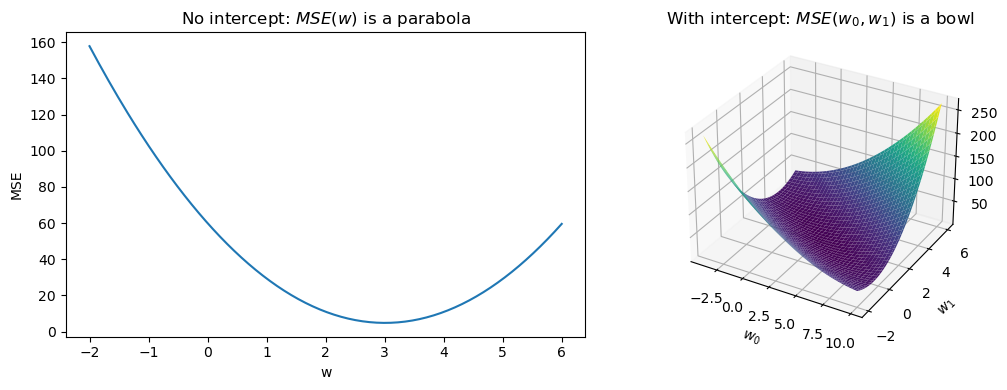

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(362)

# Synthetic data, one feature: true model y = 3 + 2x + noise
M = 50
x = rng.uniform(0, 5, M)
y = 3 + 2 * x + rng.normal(0, 1.5, M)

# Cost surface with intercept: MSE(w0, w1) -- the "bowl"
w0_grid, w1_grid = np.meshgrid(np.linspace(-4, 10, 80), np.linspace(-2, 6, 80))
cost_surface = np.array([np.mean((y - (a + b * x)) ** 2)
                         for a, b in zip(w0_grid.ravel(), w1_grid.ravel())]
                        ).reshape(w0_grid.shape)

fig = plt.figure(figsize=(11, 4))

ax = fig.add_subplot(1, 2, 1)
w_grid = np.linspace(-2, 6, 200)
ax.plot(w_grid, [np.mean((y - w * x) ** 2) for w in w_grid])
ax.set_title(r"No intercept: $MSE(w)$ is a parabola")
ax.set_xlabel("w"); ax.set_ylabel("MSE")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.plot_surface(w0_grid, w1_grid, cost_surface, cmap="viridis")
ax.set_title(r"With intercept: $MSE(w_0, w_1)$ is a bowl")
ax.set_xlabel(r"$w_0$"); ax.set_ylabel(r"$w_1$")

plt.tight_layout(); plt.show()

### The algorithm

1. Build the MSE cost function.
2. **Randomly initialize** $\mathbf{w}_0$.
3. Take the gradient $\nabla MSE(\mathbf{w}_k)$ at the current point.
4. Step **opposite** the gradient, **proportional** to its magnitude.
5. Repeat until convergence:

$$
\boxed{\;\mathbf{w}_{k+1} = \mathbf{w}_k - \eta\,\nabla MSE(\mathbf{w}_k)\;}
\qquad\text{stop when}\quad \left\lVert \mathbf{w}_{k+1} - \mathbf{w}_k \right\rVert < tol
$$

The nearer the bottom, the smaller the gradient — so the descent **slows down and stops on its own**.

### Choosing $tol$ and $\eta$

| | Too small | Too large | Common values |
|---|---|---|---|
| **$tol$** (tolerance) | Closer to the exact optimum, but more steps | Fewer steps, but further from the optimum | $10^{-3}, 10^{-6}, 10^{-9}$ |
| **$\eta$** (learning rate) | Steps too small — converges too slowly or never | Steps too large — the algorithm **diverges** | $0.01, 0.1, 1$, or adaptive $\eta = 1/k$ |

Rules of thumb: keep the **largest $tol$** that still gives you the lowest MSE; pick the
$\eta$ that avoids divergence *and* converges in reasonable time.

> **$tol$ and $\eta$ are NOT hyperparameters.** They belong to the *optimization algorithm*,
> not to the model — so they are **never cross-validated**, only set by trial and error.

### Running it

The derivation of the gradient is the **next topic**; the result we need here is

$$
\nabla MSE(\mathbf{w}) = -\frac{2}{M}\sum_{i=1}^{M}\left(y^{(i)} - \mathbf{w}^T\mathbf{x}^{(i)}\right)\mathbf{x}^{(i)}
= \frac{2}{M}X^T\left(X\mathbf{w} - \mathbf{y}\right)
$$

In [7]:
X = np.column_stack([np.ones(M), x])          # leading 1s = intercept

def mse(w):       return np.mean((y - X @ w) ** 2)
def grad_mse(w):  return (2 / M) * X.T @ (X @ w - y)

def gradient_descent(eta=0.05, tol=1e-6, max_iter=100_000):
    w, path = np.zeros(X.shape[1]), []
    for _ in range(max_iter):
        path.append(w.copy())
        w_next = w - eta * grad_mse(w)           # the update rule
        if np.linalg.norm(w_next - w) < tol:     # convergence check
            w = w_next
            break
        w = w_next
    return w, np.array(path)

w_gd, path = gradient_descent()
w_ls = np.linalg.inv(X.T @ X) @ X.T @ y          # closed-form, for comparison

print(f"Gradient Descent: w = {w_gd.round(4)}  MSE = {mse(w_gd):.6f}  steps = {len(path)}")
print(f"Least Squares   : w = {w_ls.round(4)}  MSE = {mse(w_ls):.6f}")

# Learning rate: too small is slow, too large diverges
for eta in [0.001, 0.05, 0.2]:
    w_e, p_e = gradient_descent(eta=eta, max_iter=20_000)
    print(f"eta = {eta:<6} steps = {len(p_e):<7}"
          f"{'diverged' if not np.isfinite(mse(w_e)) else f'MSE = {mse(w_e):.6f}'}")

Gradient Descent: w = [2.8367 2.0357]  MSE = 2.487396  steps = 421
Least Squares   : w = [2.8367 2.0357]  MSE = 2.487396
eta = 0.001  steps = 13578  MSE = 2.487397
eta = 0.05   steps = 421    MSE = 2.487396
eta = 0.2    steps = 20000  diverged


/var/folders/_n/0w2ts2h1483b6ccpkpr7ptg00000gn/T/ipykernel_23874/2847254459.py:4: RuntimeWarning: overflow encountered in matmul
  def grad_mse(w):  return (2 / M) * X.T @ (X @ w - y)
/var/folders/_n/0w2ts2h1483b6ccpkpr7ptg00000gn/T/ipykernel_23874/2847254459.py:10: RuntimeWarning: invalid value encountered in subtract
  w_next = w - eta * grad_mse(w)           # the update rule


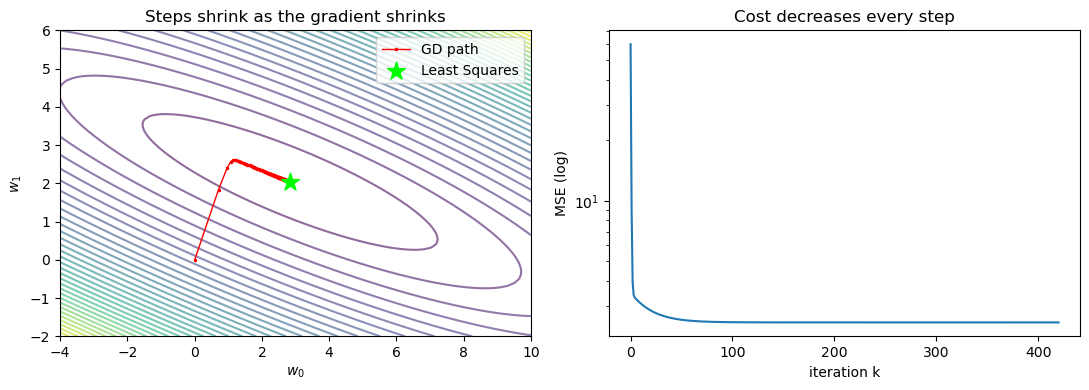

In [8]:
# Watch the descent walk down the bowl
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].contour(w0_grid, w1_grid, cost_surface, levels=40, alpha=0.6)
ax[0].plot(path[:, 0], path[:, 1], ".-", color="red", ms=3, lw=1, label="GD path")
ax[0].scatter(*w_ls, color="lime", marker="*", s=180, zorder=5, label="Least Squares")
ax[0].set_xlabel(r"$w_0$"); ax[0].set_ylabel(r"$w_1$"); ax[0].legend()
ax[0].set_title("Steps shrink as the gradient shrinks")

ax[1].plot([mse(w) for w in path]); ax[1].set_yscale("log")
ax[1].set_xlabel("iteration k"); ax[1].set_ylabel("MSE (log)")
ax[1].set_title("Cost decreases every step")

plt.tight_layout(); plt.show()

## Takeaways

- Supervised = labeled data; unsupervised = structure only; anomaly detection = either.
- Training Linear Regression = **minimizing MSE** over $\mathbf{w}$.
- Least Squares is exact but limited; **Gradient Descent generalizes** to any cost and scales.
- The update is $\mathbf{w}_{k+1} = \mathbf{w}_k - \eta\nabla MSE(\mathbf{w}_k)$; strict convexity guarantees the global minimum.
- $\eta$ too large ⇒ diverges; too small ⇒ crawls. Neither $\eta$ nor $tol$ is a hyperparameter.

**Next class:** derive $\nabla MSE(\mathbf{w})$.